# Análisis y pronóstico de BTC — Programación Funcional
### Trabajo Práctico Final · Cátedra Javier Epeloa

**Dataset:** `btc-timeseries.json` — 365 observaciones diarias consecutivas de Bitcoin (precio promedio diario entre máx y mín), sin datos faltantes.

**¿Qué hacemos acá?**
Como el profe nos aclaró que para la entrega final **no podemos usar Machine Learning**, descartamos el modelo de Gradient Boosting y scikit-learn. En su lugar, armamos dos modelos determinísticos bajo el paradigma funcional que no sean una recta ni un polinomio de juguete:

1. **Función no lineal (Tanh + Fourier):** Ajuste global con tangente hiperbólica y armónicos trigonométricos usando `curve_fit`.
2. **Modelo de Ventana Móvil (W=7 días):** Estimador funcional puro que calcula el promedio de la última semana usando `reduce` sobre tuplas inmutables.

Ambos los comparamos contra un **modelo base ingenuo** (dejar el último precio conocido, $W=1$) mediante **validación temporal paso a paso (walk-forward)** sobre 30 ventanas.


## Importación de librerías, setup y definición de métricas

In [1]:
import json
from dataclasses import dataclass
from functools import reduce
from typing import Callable, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import wilcoxon, kurtosis
from statsmodels.tsa.stattools import adfuller, acf
import platform, warnings
import scipy, statsmodels, matplotlib

from pathlib import Path
from urllib.request import urlopen

import os
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

In [2]:
plt.rcParams["figure.figsize"] = (11, 4.5)
np.random.seed(0)

# Silenciamos sólo el aviso de statsmodels sobre el formato de retorno de adfuller (no cambia ningún resultado)
warnings.filterwarnings("ignore", message=".*adfuller currently returns.*")

print(f"Python {platform.python_version()} | NumPy {np.__version__} | pandas {pd.__version__} | "
      f"SciPy {scipy.__version__} | statsmodels {statsmodels.__version__} | Matplotlib {matplotlib.__version__}")

# Métricas calculadas a mano de forma pura (sin librerías de ML)
def calc_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def calc_mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)

def calc_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

# --- Configuración inmutable (@dataclass(frozen=True)) ---
@dataclass(frozen=True)
class WFConfig:
    horizon: int = 7      # días a pronosticar hacia adelante
    step: int = 7         # avance entre ventana y ventana
    min_train: int = 150  # base inicial de días para entrenar

@dataclass(frozen=True)
class LambdaConfig:
    harmonics: int = 4
    periods_u: Tuple[float, ...] = (1.0, 0.5, 1/3, 0.25, 2.0)

WF = WFConfig()
LCFG = LambdaConfig()


Python 3.13.15 | NumPy 2.1.3 | pandas 2.2.3 | SciPy 1.16.3 | statsmodels 0.15.0 | Matplotlib 3.10.0


## 0. Calentamiento: Functor sobre listas (ejercicio de Clase 4)

Antes de meternos en el pipeline, un chequeo directo de lo pedido en la práctica de Clase 4:
implementar un Functor y **verificar sus dos leyes con `assert`, no con la intuición**.

- **Ley de identidad:** mapear la identidad no cambia nada.
- **Ley de composición:** mapear `g` y después `h` da lo mismo que mapear `h∘g` de una sola vez.

Las listas pueden utilizarse como un contexto Functor mediante `map` — lo dejamos explícito antes de reusar la misma idea
más abajo con `FitOutcome.map(...)`, donde también comprobamos las dos leyes con `assert`.


In [3]:
def fmap(f: Callable, xs: list) -> list:
    return list(map(f, xs))

xs_demo = [1, 2, 3, 4]
identidad = lambda x: x
g = lambda x: x + 1
h = lambda x: x * 2

assert fmap(identidad, xs_demo) == xs_demo, "ley de identidad falló"
assert fmap(lambda x: h(g(x)), xs_demo) == fmap(h, fmap(g, xs_demo)), "ley de composición falló"
print("Leyes de Functor verificadas sobre listas (identidad y composición). ✓")

Leyes de Functor verificadas sobre listas (identidad y composición). ✓


## 1. *Exploración* de datos (EDA)

###Carga de datos | Paneo general de los datos | Estadisticas

In [4]:
DATA_PATH = Path("btc-timeseries.json")
DATA_URL = "https://raw.githubusercontent.com/number1angel/btc-funcional-analisis/main/btc-timeseries.json"

if DATA_PATH.exists():
    with DATA_PATH.open(encoding="utf-8") as f:
        data = json.load(f) #lo buscamos si existe local
else:
    with urlopen(DATA_URL) as response:
        data = json.load(response) #sino lo sacamos del repo en Github

print("Nota del dataset:", data["nota"])

df = pd.DataFrame(data["obs"])
df["fecha"] = pd.to_datetime(df["fecha"])
n_all = len(df)

print(f"Observaciones: {n_all}")
print(f"Rango de fechas: {df['fecha'].min().date()} -> {df['fecha'].max().date()}")
print(df["precio"].describe())

Nota del dataset: precio = (max+min) del dia / 2
Observaciones: 365
Rango de fechas: 2025-08-29 -> 2026-08-28
count       365.000000
mean      82749.428356
std       17901.519853
min       59205.000000
25%       67132.050000
50%       77576.300000
75%       92569.900000
max      124613.500000
Name: precio, dtype: float64


*   El rango de fechas de los datos proporcionados es desde el 29 de Agosto de 2025 hasta el 28 de Agosto de 2026. Cuenta 1 año exacto (365 días).
*   Encontramos un promedio del valor del Bitcoin en **82749,43 USD**.
*   Al menos el 50% de las observaciones indican un valor del Bitcoin menor al del promedio calculado.
*   El mayor registro para este periodo de tiempo fue de 124613,50 USD.

In [5]:
df.head()

,t,fecha,precio
0,0,2025-08-29,109998.55
1,1,2025-08-30,108080.30
2,2,2025-08-31,108730.45
3,3,2025-09-01,108543.15
4,4,2025-09-02,110037.55


###Busqueda de inconsistencias

In [6]:
# Chequeo de integridad del dataset
faltantes = int(df.isna().sum().sum())
repetidos = int(df["fecha"].duplicated().sum())
dias_seguidos = bool((df["fecha"].diff().dropna() == pd.Timedelta(days=1)).all())
t_ok = bool((df["t"].values == np.arange(n_all)).all())
print(f"Registros de entrada: {n_all}")
print(f"Valores faltantes: {faltantes} | fechas repetidas: {repetidos} | todos los días consecutivos: {dias_seguidos} | t = 0..{n_all - 1}: {t_ok}")


Registros de entrada: 365
Valores faltantes: 0 | fechas repetidas: 0 | todos los días consecutivos: True | t = 0..364: True


En un breve análisis de inconsistencias, no se han encontrado errores.
* Todas las fechas son consecutivas.
* No hay valores faltantes en los registros.

###Comportamiento en la linea de tiempo

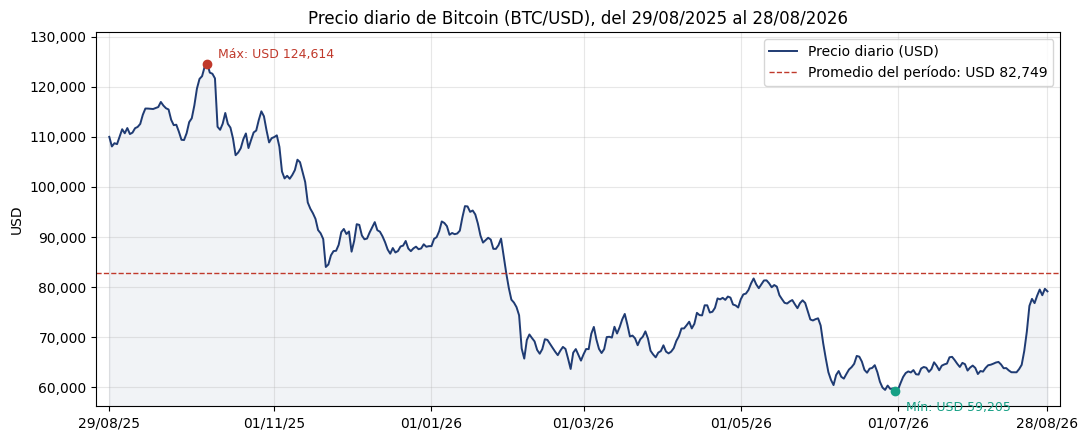

In [7]:
os.makedirs("figuras", exist_ok=True)
formato_usd = FuncFormatter(lambda v, _: f"{v:,.0f}")

def marcar_eje_fechas(ax, fechas: pd.Series) -> None:
    """Marca el primer y el último día de los datos, más el inicio de cada bimestre intermedio."""
    inicio, fin = fechas.iloc[0], fechas.iloc[-1]
    intermedias = pd.date_range(inicio + pd.offsets.MonthBegin(3), fin, freq="2MS")
    marcas = (inicio, *intermedias, fin)
    ax.set_xticks(marcas)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y"))
    ax.set_xlim(inicio - pd.Timedelta(days=5), fin + pd.Timedelta(days=5))

fechas = pd.to_datetime(df["fecha"])
serie = df["precio"].astype(float)
i_max, i_min = int(serie.idxmax()), int(serie.idxmin())
media_periodo = float(serie.mean())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(fechas, serie, lw=1.4, color="#1f3b73", label="Precio diario (USD)")
ax.fill_between(fechas, serie, serie.min() * 0.95, color="#1f3b73", alpha=0.06)
ax.axhline(media_periodo, color="#c0392b", ls="--", lw=1, label=f"Promedio del período: USD {media_periodo:,.0f}")
ax.scatter([fechas[i_max]], [serie[i_max]], color="#c0392b", zorder=3)
ax.annotate(f"Máx: USD {serie[i_max]:,.0f}", (fechas[i_max], serie[i_max]),
            xytext=(8, 4), textcoords="offset points", color="#c0392b", fontsize=9)
ax.scatter([fechas[i_min]], [serie[i_min]], color="#16a085", zorder=3)
ax.annotate(f"Mín: USD {serie[i_min]:,.0f}", (fechas[i_min], serie[i_min]),
            xytext=(8, -14), textcoords="offset points", color="#16a085", fontsize=9)
ax.set_ylim(serie.min() * 0.95, serie.max() * 1.05)
marcar_eje_fechas(ax, fechas)
ax.yaxis.set_major_formatter(formato_usd)
ax.set_title(f"Precio diario de Bitcoin (BTC/USD), del {fechas.iloc[0]:%d/%m/%Y} al {fechas.iloc[-1]:%d/%m/%Y}")
ax.set_ylabel("USD")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("figuras/figura1_precio_diario.png", dpi=150, bbox_inches="tight")
plt.show()

Se observa una **tendencia general decreciente** en el precio de Bitcoin durante gran parte de **2026**, alcanzando su minimo en el periodo hacia fines de junio. Posteriormente se observa una recuperación parcial hacia el final del periodo analizado.

Las caidas mas pronunciantes se observan hacia finales del año 2025 y a principios de 2026.

La totalidad de los valores registrados en 2025 se encuentran por encima de la media del periodo total, mientras que la gran mayoría de los valores registrados en 2026 se encuentra por debajo de la misma.

In [8]:
for año in [2025, 2026]:
    datos_año = df[df["fecha"].dt.year == año]

    print(f"\nESTADÍSTICAS {año}")

    precio_inicial = datos_año["precio"].iloc[0]
    precio_final = datos_año["precio"].iloc[-1]
    variacion = (precio_final / precio_inicial - 1) * 100

    print(f"Precio inicial: {precio_inicial:.2f} USD")
    print(f"Precio final: {precio_final:.2f} USD")
    print(f"Variacion total: {variacion:.2f}%")

    print(f"Período: {datos_año['fecha'].min().date()} → {datos_año['fecha'].max().date()}")
    print(datos_año["precio"].describe())


ESTADÍSTICAS 2025
Precio inicial: 109998.55 USD
Precio final: 88191.00 USD
Variacion total: -19.83%
Período: 2025-08-29 → 2025-12-31
count       125.000000
mean     103207.789200
std       11753.410253
min       84032.700000
25%       90611.350000
50%      108005.500000
75%      112329.950000
max      124613.500000
Name: precio, dtype: float64

ESTADÍSTICAS 2026
Precio inicial: 88194.90 USD
Precio final: 79176.55 USD
Variacion total: -10.23%
Período: 2026-01-01 → 2026-08-28
count      240.000000
mean     72094.032083
std       9136.871514
min      59205.000000
25%      64570.937500
50%      69609.175000
75%      77485.225000
max      96172.750000
Name: precio, dtype: float64


Realizando las estadisticas de los valores registrados separados por año confirmamos lo observado en el grafico.

* Media registrada en el periodo de 2025: **103207,79 USD**
* Media registrada en el periodo de 2026: **72094,03 USD**

Donde al menos el 50% de los valores registrados en 2025 se encuentran por encima de su media, y al menos el 50% de los valores registrados en 2026 se encuentran por debajo de su media.

Al comparar el primer y el ultimo registro de cada tramo, el precio disminuyo un 19,83% durante el período analizado de 2025 y un 10,23% durante 2026. Por lo tanto, aunque los precios de 2026 se mantuvieron en niveles considerablemente mas bajos, la mayor caida entre el inicio y el final de cada tramo se produjo en 2025.

### Estacionariedad y volatilidad

La diferencia entre los niveles observados en ambos períodos muestra que el precio no se mantiene alrededor de un valor estable. Para evaluar esto de manera formal, aplicamos el test ADF al precio y a sus retornos.

Si el **precio** no es estacionario pero los **retornos logarítmicos** sí, el comportamiento es
compatible con un *random walk* (típico en criptoactivos. Eso no prueba que sea un paseo aleatorio
puro (más abajo medimos la autocorrelación de los retornos), pero sí nos avisa que un ajuste
determinístico no tiene por qué predecir bien fuera de los datos conocidos.

In [9]:
precio = df["precio"].values
log_ret = np.diff(np.log(precio))

adf_precio = adfuller(precio)
adf_ret = adfuller(log_ret)

print(f"ADF sobre el precio      -> stat={adf_precio[0]:.3f}  p-valor={adf_precio[1]:.4f}")
print(f"ADF sobre log-retornos   -> stat={adf_ret[0]:.3f}  p-valor={adf_ret[1]:.4f}  (p = {adf_ret[1]:.2e})")

vol_diaria = log_ret.std(ddof=1)               # desvío estándar muestral
vol_anual = vol_diaria * np.sqrt(365)          # 365 y no 252: Bitcoin cotiza todos los días
print(f"\nRetornos calculados: {len(log_ret)}")
print(f"Volatilidad diaria (std muestral de log-retornos): {vol_diaria:.4f}  ({vol_diaria:.2%})")
print(f"Volatilidad anualizada aproximada:                 {vol_anual:.2%}")

acfs = acf(log_ret, nlags=10)
print("\nAutocorrelación de retornos (lags 1-10):", np.round(acfs[1:], 3))
print(f"Lag 1: {acfs[1]:.2f}  |  lags 2 a 10: mínimo {acfs[2:].min():.2f}, máximo {acfs[2:].max():.2f}")


ADF sobre el precio      -> stat=-1.704  p-valor=0.4292
ADF sobre log-retornos   -> stat=-6.423  p-valor=0.0000  (p = 1.77e-08)

Retornos calculados: 364
Volatilidad diaria (std muestral de log-retornos): 0.0184  (1.84%)
Volatilidad anualizada aproximada:                 35.22%

Autocorrelación de retornos (lags 1-10): [ 0.35  -0.045 -0.023  0.035  0.074  0.081  0.125 -0.044 -0.167 -0.066]
Lag 1: 0.35  |  lags 2 a 10: mínimo -0.17, máximo 0.13


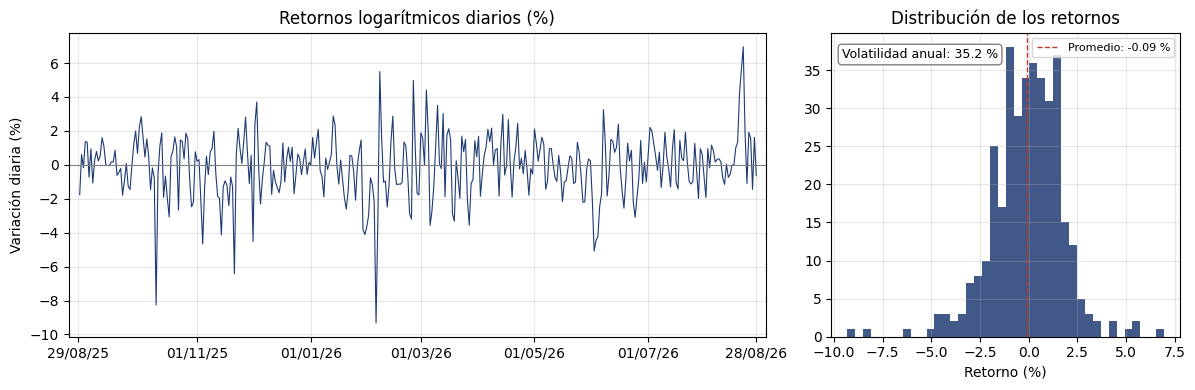

Retorno diario promedio: -0.09 %
Curtosis en exceso de los retornos: 3.18  (0 para una normal)


In [10]:
ret_pct = log_ret * 100
media_ret = float(np.mean(ret_pct))
vol_anual_pct = float(np.std(log_ret, ddof=1) * np.sqrt(365) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(fechas.iloc[1:], ret_pct, lw=0.8, color="#1f3b73")
axes[0].axhline(0, color="grey", lw=0.8)
marcar_eje_fechas(axes[0], fechas)
axes[0].set_title("Retornos logarítmicos diarios (%)")
axes[0].set_ylabel("Variación diaria (%)")
axes[0].grid(alpha=0.3)

axes[1].hist(ret_pct, bins=40, color="#1f3b73", alpha=0.85)
axes[1].axvline(media_ret, color="#c0392b", ls="--", lw=1, label=f"Promedio: {media_ret:.2f} %")
axes[1].text(0.03, 0.95, f"Volatilidad anual: {vol_anual_pct:.1f} %", transform=axes[1].transAxes,
             va="top", fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="grey"))
axes[1].set_title("Distribución de los retornos")
axes[1].set_xlabel("Retorno (%)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
fig.savefig("figuras/figura2_retornos.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Retorno diario promedio: {media_ret:.2f} %")
print(f"Curtosis en exceso de los retornos: {kurtosis(log_ret):.2f}  (0 para una normal)")

**Lectura del diagnóstico:**
* El precio no es estacionario.
* Los retornos sí son compatibles con estacionariedad.
* La volatilidad diaria es 1,84%.
* La distribución presenta más valores extremos que una normal.

Estos resultados anticipan que una curva puede ajustarse bien al comportamiento pasado del precio, pero no necesariamente mantener un buen desempeno al proyectar valores futuros.

## 2. Metodología de evaluación: Walk-Forward Validation

Ventana expansiva: entrenar con `[0, start)`, pronosticar `horizon` días, comparar contra el
valor real, deslizar `start` y repetir. Los `folds` quedan como una **tupla inmutable** — nadie
en el resto del notebook puede mutarla por accidente.

Con 150 días iniciales, horizonte 7 y paso 7 entran 30 ventanas; los últimos días de la serie que no
completan otra ventana quedan sin evaluar (la celda de abajo dice cuántos).

In [11]:
folds: Tuple[int, ...] = tuple(range(WF.min_train, n_all - WF.horizon + 1, WF.step))
print(f"Número de folds de walk-forward: {len(folds)}")
dias_usados = folds[-1] + WF.horizon
print(f"El primer fold entrena con {folds[0]} días y el último con {folds[-1]}. "
      f"Se evalúan los días 0 a {dias_usados - 1}; quedan sin evaluar los últimos {n_all - dias_usados} días de la serie.")


Número de folds de walk-forward: 30
El primer fold entrena con 150 días y el último con 353. Se evalúan los días 0 a 359; quedan sin evaluar los últimos 5 días de la serie.


## 3. Modelo 1 — Función no lineal Tanh + Fourier

$$f(u) = a_0 + a_1 \tanh\big(a_2 (u - a_3)\big) + \sum_{k=1}^{K} \big[b_k \sin(2\pi k u / P) + c_k \cos(2\pi k u / P)\big]$$

`u = t / n` es el tiempo normalizado. `make_model` es una **función de orden superior**: es una
fábrica que devuelve una función pura (`model`) — un *closure* sobre `period_u` y `harmonics`,
sin estado compartido (por dentro usa un `for` que sólo va actualizando una variable local).

Para manejar el caso en que `curve_fit` no converge con **ningún** período candidato, en vez de
dejar que el notebook explote con un error críptico (como en la versión anterior) devolvemos un
`FitOutcome`: un registro inmutable de éxito/error con un método `.map()` que **preserva la
forma** — si hubo error, lo propaga sin tocarlo; si hubo éxito, transforma el valor. Es el mismo
patrón Functor de la sección 0, aplicado a un resultado que puede fallar. (Esto anticipa el
patrón **Mónada** — Maybe/Either — que se formaliza recién en la Clase 8; acá nos alcanza con la
mitad Functor.)


In [12]:
class FitOutcome(NamedTuple):
    ok: bool
    value: Optional[Callable] = None
    rmse: Optional[float] = None
    error: Optional[str] = None
    period_u: Optional[float] = None               # período candidato elegido (sólo informativo)
    params: Optional[Tuple[float, ...]] = None     # parámetros ajustados (tupla inmutable, sólo informativo)

    def map(self, f: Callable) -> "FitOutcome":
        '''Functor: transforma `value` sólo si hubo éxito; si no, propaga el error intacto.'''
        return self if not self.ok else FitOutcome(ok=True, value=f(self.value), rmse=self.rmse,
                                                    period_u=self.period_u, params=self.params)


def make_model(period_u: float, harmonics: int) -> Callable:
    '''HOF: fábrica de funciones puras. Cada llamada devuelve un closure nuevo,
    sin compartir estado con las demás.'''
    def model(u, a0, a1, a2, a3, *bc):
        val = a0 + a1 * np.tanh(a2 * (u - a3))
        for k in range(harmonics):
            b, c = bc[2 * k], bc[2 * k + 1]
            w = 2 * np.pi * (k + 1) / period_u
            val = val + b * np.sin(w * u) + c * np.cos(w * u)
        return val
    return model


def fit_lambda_function(t_train: np.ndarray, y_train: np.ndarray, cfg: LambdaConfig = LCFG) -> FitOutcome:
    '''Función pura: misma entrada, mismo resultado; no muta `t_train`/`y_train` ni nada externo.
    Prueba varios períodos candidatos y bounds razonables (evita que curve_fit se vaya a un
    óptimo local absurdo), y se queda con el de menor RMSE in-sample.'''
    n = len(t_train)
    u = t_train / n
    bounds_lo = [-np.inf, -np.inf, 1e-6, -5.0] + [-np.inf, -np.inf] * cfg.harmonics
    bounds_hi = [np.inf, np.inf, 50.0, 5.0] + [np.inf, np.inf] * cfg.harmonics

    def try_period(period_u: float) -> FitOutcome:
        model = make_model(period_u, cfg.harmonics)
        p0 = [y_train.mean(), (y_train.max() - y_train.min()) / 2, 3, 0.5] + [1.0, 1.0] * cfg.harmonics
        try:
            popt, _ = curve_fit(model, u, y_train, p0=p0, bounds=(bounds_lo, bounds_hi), maxfev=40000)
        except (RuntimeError, ValueError) as e:
            # Sólo capturamos fallas de la optimización. Un error de programación
            # (NameError, TypeError...) tiene que explotar a la vista, no esconderse.
            return FitOutcome(ok=False, error=f"P={period_u:.3f}: {type(e).__name__}: {e}")
        rmse = calc_rmse(y_train, model(u, *popt))
        return FitOutcome(ok=True, value=(model, popt), rmse=rmse,
                          period_u=period_u, params=tuple(map(float, popt)))

    intentos: Tuple[FitOutcome, ...] = tuple(map(try_period, cfg.periods_u))
    exitos = tuple(filter(lambda o: o.ok, intentos))
    if not exitos:
        detalle = " | ".join(o.error for o in intentos)
        return FitOutcome(ok=False, error=f"curve_fit no convergió con ningún período candidato -> {detalle}")

    mejor = min(exitos, key=lambda o: o.rmse)
    # Functor en acción: transformamos (model, popt) en la función de pronóstico final
    return mejor.map(lambda mp: (lambda t_new: mp[0](np.asarray(t_new, dtype=float) / n, *mp[1])))

In [13]:
# Leyes de Functor también sobre FitOutcome (con valores de prueba simples, no con el ajuste real)
ok_demo = FitOutcome(ok=True, value=3, rmse=0.0)
err_demo = FitOutcome(ok=False, error="falla de prueba")
g_ = lambda x: x + 1
h_ = lambda x: x * 2

for demo in (ok_demo, err_demo):
    assert demo.map(lambda x: x) == demo, "ley de identidad falló en FitOutcome"
    assert demo.map(lambda x: h_(g_(x))) == demo.map(g_).map(h_), "ley de composición falló en FitOutcome"
print("Leyes de Functor verificadas sobre FitOutcome (caso éxito y caso error). ✓")


Leyes de Functor verificadas sobre FitOutcome (caso éxito y caso error). ✓


Ajuste in-sample -> MAE=2,775  RMSE=3,531  MAPE=3.44%


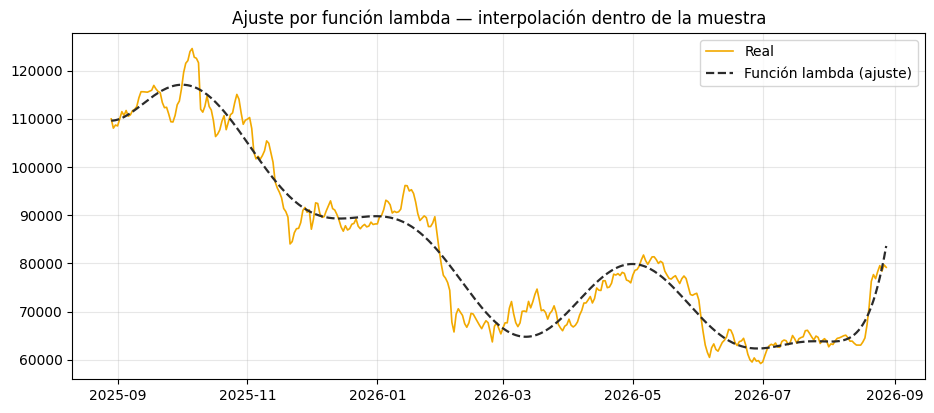

In [14]:
t_all = df["t"].values.astype(float)
y_all = df["precio"].values.astype(float)

fit_in = fit_lambda_function(t_all, y_all)
assert fit_in.ok, fit_in.error
f_lambda = fit_in.value

pred_in_sample = f_lambda(t_all)
mae_in = calc_mae(y_all, pred_in_sample)
rmse_in = calc_rmse(y_all, pred_in_sample)
mape_in = calc_mape(y_all, pred_in_sample)
print(f"Ajuste in-sample -> MAE={mae_in:,.0f}  RMSE={rmse_in:,.0f}  MAPE={mape_in:.2f}%")

fig, ax = plt.subplots()
ax.plot(df["fecha"], y_all, label="Real", lw=1.2, color="#f2a900")
ax.plot(df["fecha"], pred_in_sample, label="Función lambda (ajuste)", lw=1.6, color="#2b2b2b", ls="--")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Ajuste por función lambda — interpolación dentro de la muestra")
plt.show()

### Chequeo honesto: ¿el error bajo "in-sample" se sostiene afuera?

Probamos prediciendo los últimos 30 días **sin haberlos visto** en el ajuste.

Mismo ajuste (335 días) sobre sus datos -> MAE=2,501  RMSE=3,276  MAPE=3.11%
Mismo ajuste sobre 30 días no vistos    -> MAE=44,893  RMSE=50,898  MAPE=64.02%
Fuera de la muestra el MAPE es 20.6 veces el de dentro (el MAE, 18.0 veces).


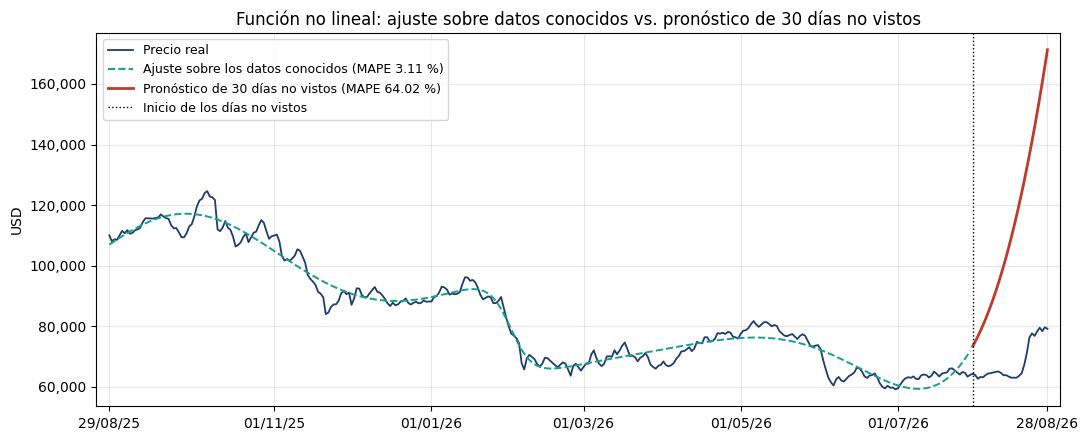

In [15]:
HOLDOUT = 30
t_tr, y_tr = t_all[:-HOLDOUT], y_all[:-HOLDOUT]
t_te, y_te = t_all[-HOLDOUT:], y_all[-HOLDOUT:]

fit_holdout = fit_lambda_function(t_tr, y_tr)
assert fit_holdout.ok, fit_holdout.error
pred_tr = fit_holdout.value(t_tr)
pred_te = fit_holdout.value(t_te)

mae_tr, rmse_tr, mape_tr = calc_mae(y_tr, pred_tr), calc_rmse(y_tr, pred_tr), calc_mape(y_tr, pred_tr)
mae_out, rmse_out, mape_out = calc_mae(y_te, pred_te), calc_rmse(y_te, pred_te), calc_mape(y_te, pred_te)
print(f"Mismo ajuste (335 días) sobre sus datos -> MAE={mae_tr:,.0f}  RMSE={rmse_tr:,.0f}  MAPE={mape_tr:.2f}%")
print(f"Mismo ajuste sobre 30 días no vistos    -> MAE={mae_out:,.0f}  RMSE={rmse_out:,.0f}  MAPE={mape_out:.2f}%")
print(f"Fuera de la muestra el MAPE es {mape_out / mape_tr:.1f} veces el de dentro (el MAE, {mae_out / mae_tr:.1f} veces).")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(fechas, y_all, lw=1.3, color="#1f3b73", label="Precio real")
ax.plot(fechas.iloc[:-HOLDOUT], pred_tr, lw=1.4, ls="--", color="#16a085",
        label=f"Ajuste sobre los datos conocidos (MAPE {mape_tr:.2f} %)")
ax.plot(fechas.iloc[-HOLDOUT:], pred_te, lw=2, color="#c0392b",
        label=f"Pronóstico de 30 días no vistos (MAPE {mape_out:.2f} %)")
ax.axvline(fechas.iloc[-HOLDOUT], color="black", ls=":", lw=1, label="Inicio de los días no vistos")
marcar_eje_fechas(ax, fechas)
ax.yaxis.set_major_formatter(formato_usd)
ax.set_title("Función no lineal: ajuste sobre datos conocidos vs. pronóstico de 30 días no vistos")
ax.set_ylabel("USD")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("figuras/figura3_extrapolacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Diagnóstico: ¿de dónde sale la explosión al extrapolar?
# tanh, seno y coseno están acotados, así que |f| <= |a0| + |a1| + suma de |b_k| y |c_k|.
# Para llegar a valores enormes fuera de la muestra hacen falta coeficientes enormes que se compensan entre sí.
def resumen_coeficientes(nombre: str, fit: FitOutcome) -> None:
    a0, a1, a2, a3, *armonicos = fit.params
    print(f"{nombre}: período elegido (en unidades de u) = {fit.period_u:.3f}")
    print(f"   a0 = {a0:,.0f} | a1 = {a1:,.0f} | a2 = {a2:.2f} | a3 = {a3:.2f}")
    print(f"   coeficientes de los armónicos: máximo en valor absoluto = {max(map(abs, armonicos)):,.0f}")
    cota = abs(a0) + abs(a1) + sum(map(abs, armonicos))
    print(f"   cota teórica de |f| = {cota:,.0f}   (precio máximo observado: {y_all.max():,.0f})")

resumen_coeficientes("Ajuste con 335 días", fit_holdout)
resumen_coeficientes("Ajuste con 365 días", fit_in)


Ajuste con 335 días: período elegido (en unidades de u) = 2.000
   a0 = 330,742 | a1 = -18,182 | a2 = 38.38 | a3 = 0.46
   coeficientes de los armónicos: máximo en valor absoluto = 427,232
   cota teórica de |f| = 1,465,775   (precio máximo observado: 124,614)
Ajuste con 365 días: período elegido (en unidades de u) = 2.000
   a0 = 2,887,443 | a1 = 13,254,455 | a2 = 3.84 | a3 = 0.61
   coeficientes de los armónicos: máximo en valor absoluto = 13,412,788
   cota teórica de |f| = 35,198,845   (precio máximo observado: 124,614)


## 4. Modelo 2 — Estimador Funcional de Ventana Móvil (W=7 días)

Siguiendo lo que nos pidió el profe de no meter Machine Learning, cambiamos el modelo de Gradient Boosting por un estimador clásico de series de tiempo basado en ventana móvil.

La idea es súper simple y funcional: tomamos los precios pasados como una tupla inmutable y armamos una función de orden superior con un closure. Usamos `reduce` para calcular la media aritmética de los últimos 7 días (la última semana observada) y proyectamos ese promedio fijo para los días siguientes.


In [17]:
# Estimador funcional puro de ventana móvil (W=7)
def modelo_naive(historial: Tuple[float, ...], horizonte: int = 7) -> Tuple[float, ...]:
    """Modelo base ingenuo: simplemente asume que mañana el precio será igual al de hoy."""
    return (historial[-1],) * horizonte

def crear_estimador_ventana(w: int) -> Callable[[Tuple[float, ...], int], Tuple[float, ...]]:
    """Closure funcional: promedia los últimos W días usando reduce."""
    def estimador(historial: Tuple[float, ...], horizonte: int = 7) -> Tuple[float, ...]:
        ventana = historial[-w:]
        media = reduce(lambda a, b: a + b, ventana) / float(w)
        return (media,) * horizonte
    return estimador

estimador_w7 = crear_estimador_ventana(w=7)

# Probamos cómo proyecta hoy con los datos completos
precios_tupla: Tuple[float, ...] = tuple(map(float, df["precio"].values))
print(f"Último precio observado (Base W=1): USD {precios_tupla[-1]:,.2f}")
print(f"Proyección Ventana Móvil (W=7):     USD {estimador_w7(precios_tupla, 7)[0]:,.2f}")


Último precio observado (Base W=1): USD 79,176.55
Proyección Ventana Móvil (W=7):     USD 78,515.01


### ¿Por qué elegimos 7 días?

Elegimos una ventana de $W=7$ días para capturar el promedio de una semana entera y filtrar el ruido diario. La duda que nos queda (y que vamos a comprobar numéricamente en la validación) es si promediar precios viejos de hace una semana no termina jugando en contra frente a Bitcoin, que se mueve muy rápido.


In [18]:
# Verificamos que la función sea pura con una pequeña prueba
muestra_prueba = (100.0, 102.0, 104.0, 106.0, 108.0, 110.0, 112.0)
assert estimador_w7(muestra_prueba, horizonte=3) == (106.0, 106.0, 106.0)
print("Todo bien: el estimador dio la media exacta sin mutar la tupla.")


Todo bien: el estimador dio la media exacta sin mutar la tupla.


## 5. Walk-forward: comparación real entre los modelos

Para no juzgar los modelos con una sola semana de suerte, los evaluamos paso a paso a lo largo de 30 ventanas temporales hacia adelante.

Para ser fieles a funcional, no usamos bucles mutables con listas y `.append()`. Evaluamos cada ventana con `map` y combinamos los resultados inmutables con `reduce` usando el patrón **Monoid** (donde la tupla vacía `()` es el elemento neutro y `+` concatena).

`evaluate_fold` recibe la serie como parámetro (arrays de sólo lectura), así que no depende de ninguna variable global.

In [19]:
class FoldResult(NamedTuple):
    start: int
    naive_mae: float
    naive_mape: float
    lambda_mae: float
    lambda_mape: float
    ventana_mae: float
    ventana_mape: float

def evaluate_fold(start: int, t_serie: np.ndarray, y_serie: np.ndarray) -> Optional[FoldResult]:
    """Evalúa los tres modelos en una ventana dada. Recibe la serie como parámetro
    (no lee variables globales) y no modifica nada de afuera."""
    t_train, p_train = t_serie[:start], y_serie[:start]
    t_test,  p_test  = t_serie[start:start + WF.horizon], y_serie[start:start + WF.horizon]

    if len(p_test) < WF.horizon:
        return None

    # 1. Modelo Base (W=1)
    pred_naive = modelo_naive(tuple(p_train), horizonte=WF.horizon)

    # 2. Función no lineal (Tanh + Fourier)
    fit = fit_lambda_function(t_train, p_train, LCFG)
    if not fit.ok:
        return None
    pred_lambda = fit.value(t_test)

    # 3. Ventana Móvil (W=7)
    pred_ventana = estimador_w7(tuple(p_train), horizonte=WF.horizon)

    p_test_arr = np.array(p_test)
    return FoldResult(
        start=start,
        naive_mae=calc_mae(p_test_arr, np.array(pred_naive)),
        naive_mape=calc_mape(p_test_arr, np.array(pred_naive)),
        lambda_mae=calc_mae(p_test_arr, np.array(pred_lambda)),
        lambda_mape=calc_mape(p_test_arr, np.array(pred_lambda)),
        ventana_mae=calc_mae(p_test_arr, np.array(pred_ventana)),
        ventana_mape=calc_mape(p_test_arr, np.array(pred_ventana)),
    )

# La serie se pasa como arrays de sólo lectura
t_serie = df["t"].values.astype(float).copy()
y_serie = df["precio"].values.astype(float).copy()
t_serie.setflags(write=False)
y_serie.setflags(write=False)

# Acumulación con reduce (patrón Monoid puro)
results_tuple: Tuple[FoldResult, ...] = reduce(
    lambda acc, x: acc + ((x,) if x is not None else ()),
    map(lambda s: evaluate_fold(s, t_serie, y_serie), folds),
    ()
)

res = pd.DataFrame([r._asdict() for r in results_tuple])
print(f"Evaluamos con éxito {len(res)} ventanas de 7 días cada una.")
print(f"Ventanas descartadas por falla del ajuste: {len(folds) - len(res)}")


Evaluamos con éxito 30 ventanas de 7 días cada una.
Ventanas descartadas por falla del ajuste: 0


                                  MAE promedio (USD)  MAPE promedio (%)
Modelo Base (W=1)                            2392.70               3.44
Ventana Móvil (W=7)                          2899.27               4.16
Función No Lineal (Tanh+Fourier)             7038.29              10.35


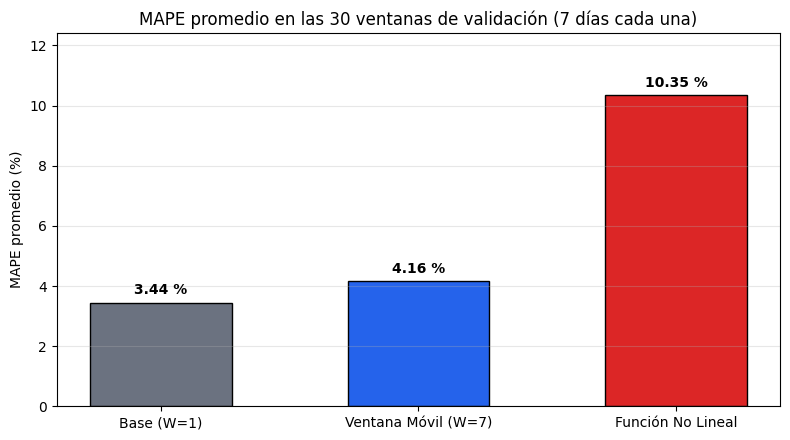

In [20]:
tabla = pd.DataFrame({
    "MAE promedio (USD)": [res.naive_mae.mean(), res.ventana_mae.mean(), res.lambda_mae.mean()],
    "MAPE promedio (%)": [res.naive_mape.mean(), res.ventana_mape.mean(), res.lambda_mape.mean()],
}, index=["Modelo Base (W=1)", "Ventana Móvil (W=7)", "Función No Lineal (Tanh+Fourier)"])
print(tabla.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(["Base (W=1)", "Ventana Móvil (W=7)", "Función No Lineal"],
                tabla["MAPE promedio (%)"], color=["#6b7280", "#2563eb", "#dc2626"], edgecolor="black", width=0.55)
ax.bar_label(barras, labels=[f"{v:.2f} %" for v in tabla["MAPE promedio (%)"]], padding=4, fontweight="bold")
ax.set_ylim(0, tabla["MAPE promedio (%)"].max() * 1.2)
ax.set_title(f"MAPE promedio en las {len(res)} ventanas de validación (7 días cada una)")
ax.set_ylabel("MAPE promedio (%)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig("figuras/figura4_mape_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Detalle para el informe: mediana, peor ventana y ventanas en que ganó el base (por MAPE)
detalle = pd.DataFrame({
    "MAE promedio (USD)":  [res.naive_mae.mean(),  res.ventana_mae.mean(),  res.lambda_mae.mean()],
    "MAPE promedio (%)":   [res.naive_mape.mean(), res.ventana_mape.mean(), res.lambda_mape.mean()],
    "MAPE mediano (%)":    [res.naive_mape.median(), res.ventana_mape.median(), res.lambda_mape.median()],
    "MAPE peor ventana (%)": [res.naive_mape.max(), res.ventana_mape.max(), res.lambda_mape.max()],
}, index=["Modelo Base (W=1)", "Ventana Móvil (W=7)", "Función No Lineal (Tanh+Fourier)"])
print(detalle.round(2))

gana_vs_w7 = int((res.naive_mape < res.ventana_mape).sum())
gana_vs_nl = int((res.naive_mape < res.lambda_mape).sum())
print(f"\nVentanas (de {len(res)}) en las que el base tuvo menor MAPE que la ventana móvil: {gana_vs_w7}")
print(f"Ventanas (de {len(res)}) en las que el base tuvo menor MAPE que la función no lineal: {gana_vs_nl}")


                                  MAE promedio (USD)  MAPE promedio (%)  \
Modelo Base (W=1)                            2392.70               3.44   
Ventana Móvil (W=7)                          2899.27               4.16   
Función No Lineal (Tanh+Fourier)             7038.29              10.35   

                                  MAPE mediano (%)  MAPE peor ventana (%)  
Modelo Base (W=1)                             2.54                  14.09  
Ventana Móvil (W=7)                           2.84                  18.60  
Función No Lineal (Tanh+Fourier)              8.62                  27.33  

Ventanas (de 30) en las que el base tuvo menor MAPE que la ventana móvil: 18
Ventanas (de 30) en las que el base tuvo menor MAPE que la función no lineal: 25


### ¿La diferencia entre los modelos es real o casualidad?

Evaluar únicamente el promedio puede ocultar la dispersión y asimetría entre ventanas. Como las predicciones de los modelos se comparan exactamente sobre las mismas ventanas temporales, utilizamos una prueba pareada no paramétrica: el **test de Wilcoxon** sobre los errores de cada fold.

Usamos la versión bilateral de `wilcoxon` (la que trae SciPy por defecto). Como hacemos **dos comparaciones**
contra el mismo modelo base, además del umbral de 0,05 miramos el umbral corregido por Bonferroni (0,05 / 2 = 0,025).


In [22]:
# wilcoxon de SciPy es bilateral por defecto
stat_ventana, p_ventana = wilcoxon(res["naive_mape"], res["ventana_mape"])
stat_lambda, p_lambda = wilcoxon(res["naive_mape"], res["lambda_mape"])

print(f"Wilcoxon (Base W=1 vs. Ventana W=7): p = {p_ventana:.4f}")
print(f"Wilcoxon (Base W=1 vs. No Lineal):   p = {p_lambda:.4e}")

ALPHA, N_COMPARACIONES = 0.05, 2
ALPHA_BONF = ALPHA / N_COMPARACIONES
print(f"\nUmbral sin corrección: {ALPHA}  |  con Bonferroni ({N_COMPARACIONES} comparaciones): {ALPHA_BONF}")
for nombre, p in (("Base vs. Ventana W=7", p_ventana), ("Base vs. No Lineal   ", p_lambda)):
    print(f"{nombre}: significativo sin corrección = {p < ALPHA} | con Bonferroni = {p < ALPHA_BONF}")


Wilcoxon (Base W=1 vs. Ventana W=7): p = 0.0473
Wilcoxon (Base W=1 vs. No Lineal):   p = 7.9945e-06

Umbral sin corrección: 0.05  |  con Bonferroni (2 comparaciones): 0.025
Base vs. Ventana W=7: significativo sin corrección = True | con Bonferroni = False
Base vs. No Lineal   : significativo sin corrección = True | con Bonferroni = True


**¿Qué significa este resultado?**
- **Base vs. Ventana Móvil ($p = 0,0473$):** el p-valor está por debajo de 0,05 pero **por encima del umbral corregido de 0,025**, así que con la corrección por dos comparaciones no podemos afirmar que la diferencia sea real: es evidencia débil. El modelo base (3,44 %) le gana en promedio a la ventana de 7 días (4,16 %). Una explicación posible es que, si el precio se parece a un paseo aleatorio, promediar precios de hace una semana arrastra un retraso (*inercia*) frente al dato de ayer; con estos datos no podemos comprobarlo.
- **Base vs. Función No Lineal ($p < 0,0001$):** la diferencia es clara y supera el umbral corregido. La función no lineal presenta un error sustancialmente mayor en la validación temporal (10,35 % promedio frente a 3,44 % del base), evidenciando la incapacidad de una curva determinística rígida para adaptarse a las fluctuaciones locales del mercado.


## 6. Proyección final hacia el futuro (30 días)

Por último, calibramos los modelos con todo el año disponible (los 365 días) y miramos qué proyectan para los próximos 30 días:

- **Modelo Base (W=1):** Traza una línea horizontal en el último precio observado (USD 79.176,55).
- **Ventana Móvil (W=7):** Traza una línea horizontal en el promedio de la última semana (USD 78.515,01).
- **Función No Lineal:** Proyecta la curva matemática hacia adelante.
- **Cono de incertidumbre:** Calculamos la volatilidad diaria de los log-retornos y usamos una banda heurística:

  $$P_0 e^{\pm 2\sigma\sqrt{h}}$$

  donde $P_0$ es el último precio observado, $\sigma$ es la desviación estándar muestral de los log-retornos y $h \in \{1, \dots, 30\}$ es el horizonte en días. El factor 2 es una aproximación a $z_{0{,}975} \approx 1{,}96$. La banda supone volatilidad constante y retornos independientes, por lo que debe interpretarse como una referencia heurística y no como un intervalo de predicción formal (está centrada en $P_0$, por lo que el modelo base queda adentro por construcción).

*Los valores de las etiquetas del gráfico se calculan en la celda, no están escritos a mano.*


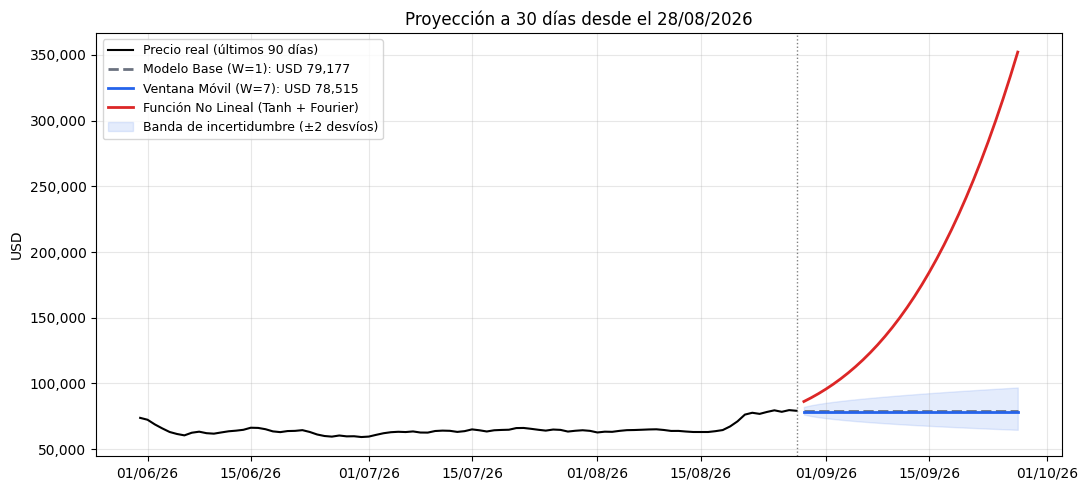

Modelo Base (W=1):     USD 79,176.55
Ventana Móvil (W=7):   USD 78,515.01
Función No Lineal:     USD 86,250.69 (día 1) -> USD 352,214.30 (día 30)
En el día 30 la función no lineal vale 4.45 veces el último precio.

Días (de 30) dentro de la banda -> Base: 30 | Ventana W=7: 30 | No lineal: 0
Banda en el día 30: USD 64,698 a USD 96,895


In [23]:
FUTURE_DAYS = 30
precios = df['precio'].values.astype(float)
t_all = df['t'].values.astype(float)
ultimo_precio = precios[-1]

# Proyecciones futuras
proy_naive = np.full(FUTURE_DAYS, ultimo_precio)
proy_w7 = np.array(estimador_w7(tuple(precios), horizonte=FUTURE_DAYS))

fit_full = fit_lambda_function(t_all, precios, LCFG)
assert fit_full.ok, fit_full.error
t_fut = np.arange(len(precios), len(precios) + FUTURE_DAYS)
proy_lambda = fit_full.value(t_fut)

# Cono estocástico (+/- 2 desvíos estándar)
log_rets = np.diff(np.log(precios))
sigma_diaria = np.std(log_rets, ddof=1)
h_steps = np.arange(1, FUTURE_DAYS + 1)
banda_sup = ultimo_precio * np.exp(2 * sigma_diaria * np.sqrt(h_steps))
banda_inf = ultimo_precio * np.exp(-2 * sigma_diaria * np.sqrt(h_steps))

fechas_fut = pd.date_range(fechas.iloc[-1] + pd.Timedelta(days=1), periods=FUTURE_DAYS, freq="D")
ult_90 = fechas.iloc[-90:]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ult_90, precios[-90:], label="Precio real (últimos 90 días)", color="black", lw=1.5)
ax.plot(fechas_fut, proy_naive, label=f"Modelo Base (W=1): USD {proy_naive[0]:,.0f}", color="#6b7280", lw=2, ls="--")
ax.plot(fechas_fut, proy_w7, label=f"Ventana Móvil (W=7): USD {proy_w7[0]:,.0f}", color="#2563eb", lw=2)
ax.plot(fechas_fut, proy_lambda, label="Función No Lineal (Tanh + Fourier)", color="#dc2626", lw=2)
ax.fill_between(fechas_fut, banda_inf, banda_sup, color="#2563eb", alpha=0.12, label="Banda de incertidumbre (±2 desvíos)")
ax.axvline(fechas.iloc[-1], color="grey", ls=":", lw=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y"))
ax.yaxis.set_major_formatter(formato_usd)
ax.set_title(f"Proyección a {FUTURE_DAYS} días desde el {fechas.iloc[-1]:%d/%m/%Y}")
ax.set_ylabel("USD")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("figuras/figura5_proyeccion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Modelo Base (W=1):     USD {proy_naive[0]:,.2f}")
print(f"Ventana Móvil (W=7):   USD {proy_w7[0]:,.2f}")
print(f"Función No Lineal:     USD {proy_lambda[0]:,.2f} (día 1) -> USD {proy_lambda[-1]:,.2f} (día {FUTURE_DAYS})")
print(f"En el día {FUTURE_DAYS} la función no lineal vale {proy_lambda[-1] / ultimo_precio:.2f} veces el último precio.")

en_banda = lambda serie: int(((serie >= banda_inf) & (serie <= banda_sup)).sum())
print(f"\nDías (de {FUTURE_DAYS}) dentro de la banda -> Base: {en_banda(proy_naive)} | Ventana W=7: {en_banda(proy_w7)} | No lineal: {en_banda(proy_lambda)}")
print(f"Banda en el día {FUTURE_DAYS}: USD {banda_inf[-1]:,.0f} a USD {banda_sup[-1]:,.0f}")


La volatilidad diaria utilizada para construir esta banda es la misma estimada durante la exploracion de los datos, con un valor de 1,84%.

## 7. Cómo probar los modelos con nuevos datos

Si tuviéramos un dato nuevo de mañana, los modelos se usan así:
- `modelo_naive(historial, h)`: toma la tupla y proyecta el último valor.
- `estimador_w7(historial, h)`: calcula el promedio de los últimos 7 días con `reduce`.
- `fit_full.value(t)`: evalúa la fórmula matemática en cualquier día futuro `t`.


In [24]:
print("Probando los estimadores:")
print(f"1. Pronóstico Base a 3 días:    {modelo_naive(tuple(map(float, precios[-10:])), horizonte=3)}")
print(f"2. Pronóstico Ventana a 3 días: {estimador_w7(tuple(map(float, precios[-10:])), horizonte=3)}")
if fit_full.ok:
    print(f"3. Curva matemática en día {len(precios)}: USD {fit_full.value(len(precios)):,.2f}")


Probando los estimadores:
1. Pronóstico Base a 3 días:    (79176.55, 79176.55, 79176.55)
2. Pronóstico Ventana a 3 días: (78515.00714285715, 78515.00714285715, 78515.00714285715)
3. Curva matemática en día 365: USD 86,250.69


##Lo que aprendimos de este trabajo

1. **Comportamiento **texto en negrita** del precio:** Durante el tramo analizado de 2025, los precios se mantuvieron en niveles considerablemente más altos que en 2026. El precio alcanzó su mínimo a fines de junio de 2026 y luego mostró una recuperación parcial, aunque finalizo por debajo del valor registrado al comienzo del dataset.
2. **En series financieras, lo simple muchas veces gana:** El test de Dickey-Fuller no dio evidencia de que el precio sea estacionario, pero sí de que los retornos lo son. En este escenario, mirar sólo el último precio ($W=1$) tuvo menor error que promediar 7 días (3,44 % contra 4,16 %); esa diferencia tiene $p = 0,0473$, que no supera el umbral corregido de 0,025, así que la tomamos como evidencia débil. Contra la función no lineal la diferencia sí es clara ($p < 0,0001$).
3. **El peligro de sobreajustar:** La función no lineal con Fourier parecía excelente adentro de la muestra, pero al proyectar hacia adelante presenta una extrapolación muy alejada del rango observado y un aumento marcado del error fuera de muestra (64 % de error). No por ser una fórmula más compleja va a predecir mejor.
4. **Programación funcional en la práctica:** Armamos todo el pipeline de punta a punta con inmutabilidad (dataclasses congeladas y tuplas), closures, `reduce`, la estructura `FitOutcome` con `.map()` (un Functor; todavía no una Mónada, porque no tiene `flat_map`) y la verificación con `assert` de las dos leyes de Functor, sobre listas y sobre `FitOutcome`. No es 100 % puro en los bordes: pandas/NumPy trabajan a su manera y `make_model` usa un `for` que actualiza una variable local.

##Limitaciones

- Un solo activo y un solo año de datos.
- Los periodos comparados de 2025 y 2026 tienen distinta duracion y no corresponden a años completos, por lo que la comparación es de únicamente los tramos incluidos en el dataset.
- Treinta ventanas son pocas para detectar diferencias sutiles, y las ventanas consecutivas no son independientes entre sí.
- Probamos un solo tamaño de ventana móvil (W=7).
- El precio es el promedio (máx+mín)/2 del día, no el cierre.
- La banda de incertidumbre supone volatilidad constante y retornos independientes.
